# **Deep Reinforcement Learning – Spring 2026, Assignment 2**

In this assignment, you will study several approaches to exploration and exploitation, different variants of Monte Carlo Tree Search (MCTS), and other fundamental reinforcement learning techniques.

Please <font color='blue'>answer all bolded questions</font> and <font color='blue'>complete all missing code sections marked with **TODO**</font>.

To work on this assignment, first create your own copy of this notebook by selecting **File > Save a copy in Drive**. Then edit the copied notebook and submit it with your completed answers.

### **Setup**

Run the following cells to install the required packages and prepare the environment.

In [ ]:
!pip install gym
!pip install pettingzoo
!git clone https://github.com/JKCooper2/gym-bandits.git
!pip install /content/gym-bandits/.
import time
import numpy as np
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
import gym
import gym_bandits
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 14.1 MB/s eta 0:00:00
Cloning into 'gym-bandits'...
remote: Enumerating objects: 73, done.
remote: Total 73 (delta 0), reused 0 (delta 0), pack-reused 73 (from 1)
Receiving objects: 100% (73/73), 14.67 KiB | 14.67 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Processing ./gym-bandits
  Preparing metadata (setup.py) ... done
  Created wheel for gym_bandits: filename=gym_bandits-0.0.2-py3-none-any.whl size=5175 sha256=0137622d8c625aaa44ca592b42a24f28e6a7d0cc8470ad3057f71d4585e21aa7
  Stored in directory: /root/.cache/pip/wheels/8a/ec/41/f6fdc40b0b6cd152ef0242b6514b08d6102d1b07dba3adc071
Successfully built gym_bandits


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# **Question 1: Exploring Exploration Strategies and Monte Carlo Tree Search in Connect Four**

In this question, you will first explore different **exploration strategies** in a **multi-armed bandit** setting, and then apply related ideas to a more structured decision-making problem: **Connect Four**.

You will begin by comparing several **exploration-exploitation** methods in bandits, including **Exploration-First**, **Epsilon-Greedy**, and **UCB1**. You will then move to **Connect Four**, where you will first observe the behavior of **random play**, and finally implement a basic **Monte Carlo Tree Search (MCTS)** agent using **UCT**.

Through this progression, you will see how ideas for balancing exploration and exploitation in bandits can also be applied in tree-based search, and how **MCTS** can make stronger decisions than random play in a deterministic two-player game.

---

## **Steps:**

### **1. Compare Exploration Strategies in Multi-Armed Bandits**
- Implement and analyze **Exploration-First**, **Epsilon-Greedy**, and **UCB1**.
- Compare how these methods balance **exploration** and **exploitation**.
- Evaluate their performance over multiple runs and discuss which method performs best based on the observed reward trends.

### **2. Explore the Connect Four Environment with Random Play**
- Interact with the provided **Connect Four** environment.
- Run **random-vs-random** games to understand the game rules, action representation, and terminal outcomes.
- Observe how the game behaves under random decision-making.

**Note:** This part is for environment familiarization only and is **not graded separately**.

### **3. Implement Basic MCTS with UCT for Connect Four**
- Develop a basic **Monte Carlo Tree Search (MCTS)** algorithm using **Upper Confidence Bounds for Trees (UCT)**.
- Implement the four main phases of MCTS: **Selection**, **Expansion**, **Simulation**, and **Backpropagation**.
- Use **random rollouts** to estimate state values and guide decision-making.
- Evaluate the MCTS agent by comparing its performance against a **random agent**.

By the end of this question, you will have implemented several core **exploration strategies**, built an **MCTS agent for Connect Four**, and observed how tree-based search can significantly improve decision-making compared with random play.

---

🎯 **How to Earn 13 Points?**

1️⃣ Correct implementation of the three bandit agents (**2 points**)  
2️⃣ Discussion and comparison of the three exploration strategies (**3 points**)  
3️⃣ Performance of your **MCTS with UCT** implementation against the random agent (**8 points**)  

**MCTS scoring rubric (50 games):**
- **48–50 wins:** 8 points  
- **45–47 wins:** 6 points  
- **42–44 wins:** 4 points  
- **39–41 wins:** 2 points  
- **0–38 wins:** 0 points  

**Note:** The random-play section is provided only to help you understand the Connect Four environment and will not be graded separately.

## Exploration-First Agent

In this section, we introduce a simple algorithm for solving multi-armed bandit problems using an **exploration-first** strategy.

- **Exploration phase:** During the first `exploration_steps` steps, the agent selects actions randomly in order to collect information about different arms.
- **Exploitation phase:** After the exploration phase, the agent selects the action with the highest estimated value based on the information collected so far.

Note that the agent continues to update its value estimates even after it starts exploiting.

We will now implement this agent below.

In [ ]:
class ExplorationFirstAgent:
    def __init__(self, k=10, exploration_steps=100):
        '''
        Args:
            k (int): Number of possible actions.
            exploration_steps (int): Number of initial steps used for pure exploration.

        Attributes:
            Q (np.array): Estimated value of each action.
            N (np.array): Number of times each action has been selected.
            t (int): Current time step.
        '''
        self.k = k
        self.exploration_steps = exploration_steps
        self.Q = np.zeros(k)
        self.N = np.zeros(k)
        self.t = 0

    def select_action(self):
        # TODO: Explore randomly for the first exploration_steps steps; exploit afterward
        if self.t < self.exploration_steps:
            return np.random.randint(self.k)
        else:
            return np.argmax(self.Q)


    def update(self, action, reward):
        # TODO: Update the action count, value estimate, and time step
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]
        self.t += 1


## Epsilon-Greedy Agent

Another popular strategy for multi-armed bandits is **epsilon-greedy exploration**, which balances **exploration** and **exploitation**.

The main idea is:
- With probability $\epsilon$, the agent selects a random action (**exploration**).
- With probability $1 - \epsilon$, the agent selects the action with the highest estimated value (**exploitation**).

By adjusting $\epsilon$, we can control how exploratory or conservative the agent behaves.

We will now implement this agent.

In [ ]:
class EpsilonGreedyAgent:
    def __init__(self, k=10, epsilon=0.1):
        """
        Args:
            k (int): Number of possible actions.
            epsilon (float): Probability of selecting a random action.
        """
        self.k = k
        self.epsilon = epsilon
        self.Q = np.zeros(k)
        self.N = np.zeros(k)

    def select_action(self):
        # TODO: With probability epsilon, explore; otherwise, exploit
        if np.random.random() < self.epsilon:
            return np.random.randint(self.k)
        else:
            return np.argmax(self.Q)


    def update(self, action, reward):
        # TODO: Update the action count and value estimate
        self.N[action] += 1
        self.Q[action] += (reward - self.Q[action]) / self.N[action]


## UCB1 Agent

Unlike **Exploration-First**, which separates exploration and exploitation into two phases, or **Epsilon-Greedy**, which relies on random exploration, the **UCB1 (Upper Confidence Bound)** agent balances exploration and exploitation based on uncertainty.

Instead of following a fixed exploration schedule or randomly exploring actions, UCB1 prefers actions that either have high estimated rewards or have not been explored enough.

Your task is to implement the `select_action` and `update` methods for a UCB1 agent so that it can use confidence bounds to make more effective decisions.

---

## UCB1 Formula

The UCB1 algorithm selects an action `a` according to the following rule:

$Q(a) + c \cdot \sqrt{\frac{\log t}{N(a)}}$

where:
- `Q(a)` is the estimated reward for action `a`
- `N(a)` is the number of times action `a` has been selected
- `t` is the total number of time steps
- `c` is the exploration coefficient

To implement UCB1, you should:

1. **Ensure that each action is selected at least once** before applying the UCB formula.  
2. **Compute the UCB value for every action** and choose the action with the highest value.  
3. **Update the estimated reward `Q(a)`** after each action using incremental averaging:

$Q(a) \gets Q(a) + \frac{R - Q(a)}{N(a)}$

where `R` is the reward received after selecting action `a`.

In [ ]:
class UCB1Agent:
    def __init__(self, k=10, c=1.0):
        """
        Args:
            k (int): Number of possible actions.
            c (float): Exploration coefficient controlling the balance
                between exploration and exploitation.
        """
        self.k = k
        self.c = c
        self.Q = np.zeros(k, dtype=float)
        self.N = np.zeros(k, dtype=int)
        self.t = 0

    def select_action(self):
        # TODO: Select each untried action at least once before applying UCB1
        for a in range(self.k):
            if self.N[a] == 0:
                return a

        # TODO: Compute the UCB1 value for each action
        ucb_values = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)

        # TODO: Select the action with the highest UCB1 value
        return np.argmax(ucb_values)

    def update(self, action, reward):
        # TODO: Update the visit count for the selected action
        self.N[action] += 1

        # TODO: Update the estimated value of the selected action
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

        # TODO: Update the total number of time steps
        self.t += 1


## Comparing Exploration Strategies in Multi-Armed Bandits

In this experiment, we compare the performance of three exploration strategies—**Exploration-First**, **Epsilon-Greedy**, and **UCB1**—in a **multi-armed bandit** environment.

Each strategy is evaluated for **1000** steps over **50** independent runs, and the average reward curves are plotted for comparison.

You do not need to modify the code below. Simply run the cell and observe the performance differences among the three agents.

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:174: UserWarning: WARN: Future gym versions will require that `Env.reset` can be passed a `seed` instead of using `Env.seed` for resetting the environment random number generator.
  logger.warn(
/usr/local/lib/python3.12/dist-packages/gym/utils/passive_env_checker.py:190: UserWarning: WARN: Future gym versions will require 

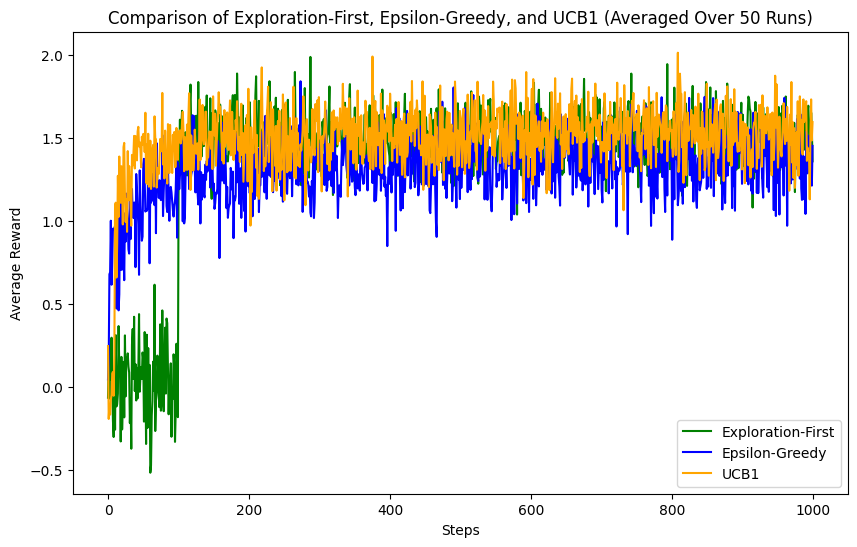

Final 200-step Avg Reward - Exploration-First: 1.511, Epsilon-Greedy: 1.373, UCB1: 1.527
✅ UCB1 performs the best in the long run!


In [ ]:
def simulate(env, agent, steps=1000):
    rewards = np.zeros(steps)

    env.reset()  # old gym_bandits API: reset() takes no seed

    for t in range(steps):
        action = agent.select_action()
        observation, reward, done, info = env.step(action)
        agent.update(action, reward)
        rewards[t] = reward

    return rewards


num_runs = 50
steps = 1000

all_rewards_exp_first = []
all_rewards_eg = []
all_rewards_ucb = []

for run in range(num_runs):
    # Exploration-First
    np.random.seed(run)
    env = gym.make("BanditTenArmedGaussian-v0")
    exp_first_agent = ExplorationFirstAgent(k=10, exploration_steps=100)
    rewards_exp_first = simulate(env, exp_first_agent, steps)
    all_rewards_exp_first.append(rewards_exp_first)

    # Epsilon-Greedy
    np.random.seed(run)
    env = gym.make("BanditTenArmedGaussian-v0")
    epsilon_greedy_agent = EpsilonGreedyAgent(k=10, epsilon=0.1)
    rewards_eg = simulate(env, epsilon_greedy_agent, steps)
    all_rewards_eg.append(rewards_eg)

    # UCB1
    np.random.seed(run)
    env = gym.make("BanditTenArmedGaussian-v0")
    ucb_agent = UCB1Agent(k=10, c=1.0)
    rewards_ucb = simulate(env, ucb_agent, steps)
    all_rewards_ucb.append(rewards_ucb)

avg_rewards_exp_first = np.mean(all_rewards_exp_first, axis=0)
avg_rewards_eg = np.mean(all_rewards_eg, axis=0)
avg_rewards_ucb = np.mean(all_rewards_ucb, axis=0)

plt.figure(figsize=(10, 6))
plt.plot(avg_rewards_exp_first, label="Exploration-First", color="green")
plt.plot(avg_rewards_eg, label="Epsilon-Greedy", color="blue")
plt.plot(avg_rewards_ucb, label="UCB1", color="orange")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Comparison of Exploration-First, Epsilon-Greedy, and UCB1 (Averaged Over 50 Runs)")
plt.legend()
plt.show()

final_avg_exp_first = np.mean(avg_rewards_exp_first[-200:])
final_avg_eg = np.mean(avg_rewards_eg[-200:])
final_avg_ucb = np.mean(avg_rewards_ucb[-200:])

print(
    f"Final 200-step Avg Reward - Exploration-First: {final_avg_exp_first:.3f}, "
    f"Epsilon-Greedy: {final_avg_eg:.3f}, UCB1: {final_avg_ucb:.3f}"
)

if final_avg_exp_first > final_avg_eg and final_avg_exp_first > final_avg_ucb:
    print("✅ Exploration-First performs the best in the long run!")
elif final_avg_eg > final_avg_exp_first and final_avg_eg > final_avg_ucb:
    print("✅ Epsilon-Greedy performs the best in the long run!")
else:
    print("✅ UCB1 performs the best in the long run!")

### **Question (3 pts)**

Based on the plotted results, which exploration strategy (**Exploration-First, Epsilon-Greedy, or UCB1**) performed the best in this multi-armed bandit environment? Explain **why**.

In your discussion, compare how the three methods balance **exploration** and **exploitation**, and relate your explanation to the observed reward curves. Your answer should include:

1. **Which method performed the best overall**, based on the plotted results.  
2. **Why this method performed better** in this environment.  
3. The **strengths and weaknesses** of the other two methods.  
4. How the exploration behavior of each strategy affects its **early-stage** and **long-term** performance.  

**Answer:**

1. UCB1 performed the best overall, achieving the highest final 200-step average reward of 1.527, narrowly beating Exploration-First (1.511) and clearly outperforming Epsilon-Greedy (1.373). Looking at the plot, UCB1 (orange) consistently occupies the upper envelope of the reward curves from roughly step 150 onward.

2. UCB1's advantage comes from how it allocates exploration effort. Rather than exploring randomly (like the other two methods), UCB1 uses an uncertainty-driven exploration bonus: c·√(ln t / N(a)). This means it preferentially revisits arms whose value estimates are still uncertain (low N(a)), while naturally stopping exploration of arms it has already confidently identified as suboptimal.
The result is that UCB1 spends fewer total pulls on bad arms compared to Exploration-First (which samples all arms uniformly during its exploration phase) and Epsilon-Greedy (which picks random arms 10% of the time forever). UCB1's exploration is targeted — it gathers information where information is actually needed — and it decays gracefully as confidence grows, without requiring a hard-coded schedule or fixed exploration rate.

3.
- Exploration-First

  Strength: After the exploration phase ends (step 100), it commits fully to the best-known arm with zero exploration waste. This is why its long-term reward (1.511) is close to UCB1's — once it locks in, it exploits 100% of the time.
  
  Weakness: The first 100 steps are purely random, producing very low (even negative) average rewards visible in the plot. The exploration budget is also rigid: 100 steps give each arm only ~10 samples on average, which may not be enough to reliably identify the best arm in a Gaussian bandit. If it picks the wrong arm at step 100, it's stuck.

- Epsilon-Greedy:

  Strength: Simple, no phases, and it starts exploiting immediately — you can see it ramps up faster than Exploration-First in the first ~100 steps.
  
  Weakness: The fixed ε = 0.1 means 10% of all pulls are random forever, even at step 999 when the agent already knows which arm is best. This permanent exploration tax is directly visible in the plot: the blue curve sits consistently below the other two methods in the later stages, and its final average (1.373) reflects ~10% reward dilution from pulling suboptimal arms.

4.
- Early-stage (steps 0–150):

  Exploration-First shows the worst early performance — deeply negative rewards around steps 0–100 — because it is purely exploring with random pulls across all 10 arms.
  
  Epsilon-Greedy performs best early on because it starts exploiting from step 1: even with a rough Q-estimate after a few pulls, 90% greedy action selection yields decent rewards quickly.
  
  UCB1 falls between the two early on. It must pull each arm once (10 steps of forced exploration), then rapidly focuses on promising arms while still occasionally revisiting uncertain ones.

- Long-term (steps 200–1000):

  UCB1 dominates because its exploration bonus shrinks as O(√(ln t / N)), naturally transitioning to near-pure exploitation of the best arm while retaining the ability to correct if early estimates were noisy.

  Exploration-First is a close second — it exploits 100% after step 100 — but it can't recover from misidentification during the fixed exploration window.

  Epsilon-Greedy trails because its exploration rate never decays. The 10% random pull tax is a constant drag on asymptotic reward, and this gap would only widen with a longer horizon.



## Applying Exploration Ideas to Connect Four with MCTS

Now that you have explored different **exploration strategies** and developed an understanding of how they balance exploration and exploitation, it is time to apply related ideas to a more structured decision-making problem: **Connect Four**.

In this section, you will implement **Monte Carlo Tree Search (MCTS) with UCT** for Connect Four and use it to improve decision-making over random play.

Before diving into the implementation, take a moment to build some intuition for the game itself. Connect Four is a two-player, turn-based, deterministic board game in which players alternately drop pieces into one of the columns, and the first player to align four pieces horizontally, vertically, or diagonally wins.

You **do not** need to modify the provided Connect Four environment code unless explicitly instructed. However, if minor changes help with debugging or experimentation, you may make them as long as they **do not change the fundamental game rules or environment behavior**.

In the following cells, you will:
1. Observe how **random play** behaves in Connect Four.
2. Implement **MCTS with UCT** to improve action selection.
3. Compare the behavior of **random agents** and **MCTS-based agents**.

Now, let’s move on to implementing **MCTS for Connect Four**, building on what you learned about exploration and structured decision-making.

## Connect Four Environment Setup

In this section, we move from multi-armed bandit problems to a two-player game environment: **Connect Four**.

We will use the provided **PettingZoo Connect Four** environment, so you do **not** need to implement the game rules yourself. Your goal is to interact with the environment correctly and use it to test different decision-making strategies.

We will first observe how the game behaves under **random play**, and then move on to stronger search-based methods such as **MCTS**.

In [ ]:
from pettingzoo.classic import connect_four_v3
from IPython.display import clear_output


env = connect_four_v3.env(render_mode=None)

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

## Visualizing a Random Game in Connect Four

Before running multiple random-play experiments, let us first observe a single random game step by step.

This helps us understand:
- how the board is represented,
- how actions correspond to columns,
- how pieces fall to the lowest available position,
- and how the game ends.

You do **not** need to modify the code in this part. Simply run the cell and observe how the environment works.

In [ ]:
def print_board(board_flat):
    board = np.array(board_flat).reshape(6, 7)
    symbol_map = {0: ".", 1: "X", 2: "O"}

    print("  0 1 2 3 4 5 6")
    for row in board:
        print(" ", " ".join(symbol_map[int(x)] for x in row))
    print()


def play_random_game_with_text(seed=None, delay=0.8):
    env = connect_four_v3.env(render_mode=None)
    env.reset(seed=seed)

    final_rewards = {agent: 0 for agent in env.possible_agents}
    move_idx = 0

    clear_output(wait=True)
    print("Initial board")
    print_board(env.unwrapped.board)
    time.sleep(delay)

    for agent in env.agent_iter():
        observation, reward, termination, truncation, info = env.last()

        if termination or truncation:
            action = None
        else:
            legal_actions = np.flatnonzero(observation["action_mask"])
            action = np.random.choice(legal_actions)

        env.step(action)

        clear_output(wait=True)
        print(f"Move {move_idx}: {agent} -> action {action}")
        print_board(env.unwrapped.board)

        move_idx += 1
        time.sleep(delay)

        if all(env.terminations.values()) or all(env.truncations.values()):
            final_rewards = env.rewards.copy()
            break


    env.close()
    return final_rewards

play_random_game_with_text(seed=0, delay=0.8)

Move 26: player_0 -> action 3
  0 1 2 3 4 5 6
  . . . . . . .
  . . X . . . O
  . . O X . X X
  O X O X O O O
  O O X X O X X
  X O X X X O O



{'player_0': 1, 'player_1': -1}

## Random vs Random in Connect Four

Now that we have seen how a single random game unfolds, let us run multiple **random-vs-random** games and summarize the overall outcomes.

This provides a simple baseline before implementing more advanced decision-making methods such as **MCTS**.

Again, you do **not** need to modify the code in this part. Just run the cell to get a basic understanding of the environment and the behavior of random play.

In [ ]:
def play_random_game(seed=None):
    env = connect_four_v3.env(render_mode=None)
    env.reset(seed=seed)

    final_rewards = {agent: 0 for agent in env.possible_agents}

    for agent in env.agent_iter():
        observation, reward, termination, truncation, info = env.last()

        if termination or truncation:
            action = None
        else:
            legal_actions = np.flatnonzero(observation["action_mask"])
            action = np.random.choice(legal_actions)

        env.step(action)

        if all(env.terminations.values()) or all(env.truncations.values()):
            final_rewards = env.rewards.copy()
            break

    env.close()
    return final_rewards

num_games = 20
results = {"player_0_win": 0, "player_1_win": 0, "draw": 0}

for i in range(num_games):
    final_rewards = play_random_game(seed=i)

    if final_rewards["player_0"] == 1:
        results["player_0_win"] += 1
    elif final_rewards["player_1"] == 1:
        results["player_1_win"] += 1
    else:
        results["draw"] += 1

print(f"Random vs Random over {num_games} games")
print(f"Player 0 wins: {results['player_0_win']}")
print(f"Player 1 wins: {results['player_1_win']}")
print(f"Draws: {results['draw']}")

Random vs Random over 20 games
Player 0 wins: 7
Player 1 wins: 13
Draws: 0


## Monte Carlo Tree Search (MCTS) for Connect Four

Now that you have interacted with the Connect Four environment and observed the behavior of random play, you will implement **Monte Carlo Tree Search (MCTS)** with **UCT**.

Compared with random action selection, MCTS performs structured search by repeatedly simulating possible future outcomes. This allows the agent to make better decisions by balancing **exploration** and **exploitation** during search.

MCTS repeatedly builds a search tree through four key steps:

1. **Selection**: Traverse the tree using the UCT rule.  
2. **Expansion**: Add a new child node for an untried action.  
3. **Simulation**: Play randomly until the game ends.  
4. **Backpropagation**: Propagate the simulation result back up the tree.  

Your goal is to implement these components and use MCTS to choose stronger actions than random play.

Before implementing the search algorithm, we first define a lightweight **Connect Four state representation** that will be used during tree search. You do **not** need to modify this helper code.

In [ ]:
import numpy as np

ROWS = 6
COLS = 7


class ConnectFourState:
    def __init__(self, board=None, current_player=1):
        """
        Lightweight Connect Four state for search.

        Args:
            board: A (6, 7) numpy array.
                   0 = empty, 1 = player_1, 2 = player_2
            current_player: The player to move (1 or 2).
        """
        if board is None:
            self.board = np.zeros((ROWS, COLS), dtype=np.int8)
        else:
            self.board = board.copy()

        self.current_player = current_player

    def clone(self):
        return ConnectFourState(self.board, self.current_player)

    def legal_actions(self):
        """Return all legal columns."""
        return [c for c in range(COLS) if self.board[0, c] == 0]

    def apply_action(self, action):
        """
        Drop a piece into the selected column and return the next state.
        """
        next_state = self.clone()

        for r in range(ROWS - 1, -1, -1):
            if next_state.board[r, action] == 0:
                next_state.board[r, action] = self.current_player
                break

        next_state.current_player = 3 - self.current_player
        return next_state

    def is_full(self):
        return np.all(self.board[0] != 0)

    def check_winner(self):
        """
        Return:
            0 if no winner,
            1 if player 1 wins,
            2 if player 2 wins
        """
        board = self.board

        # Horizontal
        for r in range(ROWS):
            for c in range(COLS - 3):
                x = board[r, c]
                if x != 0 and x == board[r, c + 1] == board[r, c + 2] == board[r, c + 3]:
                    return x

        # Vertical
        for r in range(ROWS - 3):
            for c in range(COLS):
                x = board[r, c]
                if x != 0 and x == board[r + 1, c] == board[r + 2, c] == board[r + 3, c]:
                    return x

        # Diagonal down-right
        for r in range(ROWS - 3):
            for c in range(COLS - 3):
                x = board[r, c]
                if x != 0 and x == board[r + 1, c + 1] == board[r + 2, c + 2] == board[r + 3, c + 3]:
                    return x

        # Diagonal up-right
        for r in range(3, ROWS):
            for c in range(COLS - 3):
                x = board[r, c]
                if x != 0 and x == board[r - 1, c + 1] == board[r - 2, c + 2] == board[r - 3, c + 3]:
                    return x

        return 0

    def is_terminal(self):
        return self.check_winner() != 0 or self.is_full()

    def outcome_for_player(self, player):
        """
        Return the terminal outcome from the given player's perspective:
            +1 if the player wins
            -1 if the player loses
             0 if draw
        """
        winner = self.check_winner()

        if winner == 0:
            return 0
        elif winner == player:
            return 1
        else:
            return -1


def print_search_board(state):
    symbol_map = {0: ".", 1: "X", 2: "O"}
    print("  0 1 2 3 4 5 6")
    for row in state.board:
        print(" ", " ".join(symbol_map[int(x)] for x in row))
    print()

## MCTS Node

Each node in the search tree stores:
- the current game state,
- its parent node,
- the action taken from the parent,
- its child nodes,
- visit counts,
- and accumulated value estimates.

You will now implement several basic components of the MCTS node.

In [ ]:
class MCTSNode:
    def __init__(self, state, parent=None, action_taken=None):
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.children = {}

        # TODO: Initialize the list of actions that have not been expanded yet.
        self.untried_actions = list(state.legal_actions())

        self.visits = 0
        self.value_sum = 0.0

    def is_fully_expanded(self):
        # TODO: Return True if there are no remaining untried actions.
        return len(self.untried_actions) == 0


    def value(self):
        # TODO: Return the average value of this node.
        # If the node has not been visited yet, return 0.
        if self.visits == 0:
            return 0.0
        return self.value_sum / self.visits


## Core MCTS Functions

You will now implement the four main steps of MCTS:
- **Selection**
- **Expansion**
- **Simulation**
- **Backpropagation**

During **selection**, we use the **UCT** rule:
$
\text{UCT}(a) = Q(a) + c \sqrt{\frac{\log N}{n(a)}}
$

In this implementation, each node stores its value from the perspective of the **player to move at that node**.  
As a result, when a parent node evaluates one of its children, the child's value must be **negated** to convert it back to the parent's perspective.

In [ ]:
def uct_score(parent, child, c=1.4):
    # TODO:If the child has never been visited, return +infinity
    # so that it is explored before already-visited children.
    if child.visits == 0:
        return float('inf')

    # TODO:Compute the exploitation term.
    exploitation = -child.value()

    # TODO: Compute the exploration term using the UCT formula.
    exploration = c * np.sqrt(np.log(parent.visits) / child.visits)

    return exploitation + exploration

def select_child(node, c=1.4):
    # TODO:Select the child with the highest UCT score.
    return max(node.children.values(), key=lambda child: uct_score(node, child, c))

def expand(node):
    # TODO: Randomly choose one untried action, remove it from the untried list,
    # create the corresponding child node, and add it to node.children.
    action = node.untried_actions.pop(np.random.randint(len(node.untried_actions)))
    child_state = node.state.apply_action(action)
    child_node = MCTSNode(child_state, parent=node, action_taken=action)
    node.children[action] = child_node
    return child_node

def rollout(state):
    # TODO:Perform random simulation until reaching a terminal state.
    rollout_player = state.current_player
    current = state.clone()
    while not current.is_terminal():
        action = np.random.choice(current.legal_actions())
        current = current.apply_action(action)

    # TODO:Return the terminal outcome from the perspective
    # of the player who was to move at the start of the rollout.
    return current.outcome_for_player(rollout_player)


def backpropagate(node, value):
    # TODO:Update visits and value_sum while moving back to the root.
    # Since players alternate turns, flip the sign of value
    # after moving to the parent node.
    while node is not None:
        node.visits += 1
        node.value_sum += value
        value = -value
        node = node.parent


## Running MCTS

Now combine the four steps above into a complete MCTS procedure.

For each simulation:
1. Start at the root node.
2. Repeatedly apply **selection** until reaching a node that is not fully expanded.
3. Apply **expansion** if possible.
4. Run a **simulation** from the resulting state.
5. Apply **backpropagation**.

After all simulations are completed, choose the action whose child node has the highest visit count.

In [ ]:
def run_mcts(root_state, num_simulations=50, c=1.4):

    root = MCTSNode(root_state)

    for _ in range(num_simulations):
        node = root

        # TODO: Selection: keep moving down while the node is fully expanded,
        # has children, and is not terminal.
        while node.is_fully_expanded() and len(node.children) > 0 and not node.state.is_terminal():
            node = select_child(node, c)

        # TODO:Expansion: if the node is not terminal and still has untried actions,
        # expand one child.
        if not node.state.is_terminal() and not node.is_fully_expanded():
            node = expand(node)

        # TODO:Simulation: estimate the value by random rollout.
        value = rollout(node.state)

        # TODO:Backpropagation: propagate the value back to the root.
        backpropagate(node, value)

    # TODO:Select the action whose child has the highest visit count.
    best_action = max(root.children, key=lambda a: root.children[a].visits)

    return best_action, root

## Testing MCTS on the Initial State

Before evaluating MCTS more systematically, let us first test whether it can select a valid action from the initial state.

This serves as a simple sanity check:
- the search should run without errors,
- the returned action should be legal,
- and different root actions should accumulate different visit counts based on the search results.

You do **not** need to modify the code in this part. Simply run the cell and inspect the output.

In [ ]:
initial_state = ConnectFourState()
best_action, root = run_mcts(initial_state, num_simulations=50, c=1.4)

print("Chosen action:", best_action)
print("Root child statistics:")
for action, child in sorted(root.children.items()):
    print(f"Action {action}: visits = {child.visits}, value = {child.value():.3f}")

Chosen action: 2
Root child statistics:
Action 0: visits = 8, value = 0.000
Action 1: visits = 2, value = 1.000
Action 2: visits = 22, value = -0.455
Action 3: visits = 4, value = 0.500
Action 4: visits = 2, value = 1.000
Action 5: visits = 10, value = -0.200
Action 6: visits = 2, value = 1.000


## MCTS vs Random

Now let us use the implemented **MCTS** agent to play against a **random agent**.

We expect MCTS to make stronger decisions than purely random play, since it performs structured search before choosing an action.

You do **not** need to modify the code in this part. Simply run the cell and observe how the MCTS agent behaves in a single game.

In [ ]:
def play_mcts_vs_random(num_simulations=100, seed=None, mcts_player=1, verbose=False):
    if seed is not None:
        np.random.seed(seed)

    state = ConnectFourState()

    if verbose:
        print("Initial board")
        print_search_board(state)

    move_idx = 0

    while not state.is_terminal():
        if state.current_player == mcts_player:
            action, _ = run_mcts(state, num_simulations=num_simulations, c=0.5)
            player_name = "MCTS"
        else:
            action = np.random.choice(state.legal_actions())
            player_name = "Random"

        state = state.apply_action(action)

        if verbose:
            print(f"Move {move_idx}: {player_name} -> action {action}")
            print_search_board(state)

        move_idx += 1

    result = state.outcome_for_player(mcts_player)

    if verbose:
        if result == 1:
            print("MCTS wins!")
        elif result == -1:
            print("Random wins!")
        else:
            print("Draw!")

    return result

result = play_mcts_vs_random(num_simulations=50, seed=0, mcts_player=1, verbose=True)
print("Game result from MCTS perspective:", result)

Initial board
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .

Move 0: MCTS -> action 1
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . X . . . . .

Move 1: Random -> action 5
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . X . . . O .

Move 2: MCTS -> action 5
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . X .
  . X . . . O .

Move 3: Random -> action 4
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . X .
  . X . . O O .

Move 4: MCTS -> action 2
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . X .
  . X X . O O .

Move 5: Random -> action 0
  0 1 2 3 4 5 6
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . . .
  . . . . . X .
  O X X . O O .

Move 6: MCTS -> action 6
  0 1 2 3 4 5 

## Evaluating MCTS Against Random Play

After observing a single game between the MCTS agent and a random agent, let us evaluate its overall performance over multiple games.

To make the comparison fairer, the MCTS agent alternates between playing as the **first player** and the **second player**.

⚠️ **Do not modify the evaluation code in this part. Any changes to the evaluation code will result in a score of 0 for this part.**

To receive full credit, your MCTS agent must win at least **48 out of 50** games against the random agent.

In [ ]:
def evaluate_mcts_vs_random(num_games=50, num_simulations=50):
    results = {
        "mcts_win": 0,
        "random_win": 0,
        "draw": 0,
    }

    for i in range(num_games):
        # Alternate the side played by MCTS
        mcts_player = 1 if i % 2 == 0 else 2

        result = play_mcts_vs_random(
            num_simulations=num_simulations,
            seed=i,
            mcts_player=mcts_player,
            verbose=False,
        )

        if result == 1:
            results["mcts_win"] += 1
        elif result == -1:
            results["random_win"] += 1
        else:
            results["draw"] += 1

    return results

num_games = 50
results = evaluate_mcts_vs_random(num_games=num_games, num_simulations=50)

print(f"MCTS vs Random over {num_games} games")
print(f"MCTS wins: {results['mcts_win']}")
print(f"Random wins: {results['random_win']}")
print(f"Draws: {results['draw']}")
mcts_win_rate = results["mcts_win"] / num_games
print(f"MCTS win rate: {mcts_win_rate:.3f}")

MCTS vs Random over 50 games
MCTS wins: 47
Random wins: 3
Draws: 0
MCTS win rate: 0.940


# **Question 2: AlphaZero-Style Self-Play for Connect Four**

In this question, you will build a simplified **AlphaZero-style agent** for Connect Four by combining a neural network with **MCTS**.

In Question 1, MCTS estimated state values using **random rollouts**. In this question, search will instead be guided by a neural network that predicts:

- a **policy** over actions, which provides prior probabilities for search,  
- and a **value** estimate, which predicts the expected game outcome.

Using these predictions, you will implement a simplified AlphaZero-style pipeline:

1. Encode the Connect Four board as neural network input.  
2. Build a small **policy-value network**.  
3. Use the network inside **PUCT-based MCTS**.  
4. Generate self-play games and collect search-based training targets.  
5. Store the data in a replay buffer.  
6. Train the network using the collected self-play data.

---

🎯 **How to Earn 17 Points?**

1️⃣ Performance of the trained **network policy only** against the random agent (**4 points**)  
2️⃣ Performance of the trained **policy-value + MCTS** agent against the **rollout-based MCTS** agent (**7 points**)  
3️⃣ Written questions (**6 points**)  

### **Direct network vs random (50 games)**
- **42–50 wins:** 4 points  
- **35–41 wins:** 2 points  
- **0–34 wins:** 0 points  

### **Policy-value + MCTS vs rollout-based MCTS (50 games)**
- **33–50 wins:** 7 points  
- **30–32 wins:** 4 points  
- **28–29 wins:** 1 point  
- **0–27 wins:** 0 points  

### **Written questions**
- **Question 1:** 2 points  
- **Question 2:** 2 points  
- **Question 3:** 2 points  

## State Encoding

Before training a neural network, we need to convert each Connect Four board into a tensor representation.

In this assignment, we use **three feature planes**:

- **Plane 0:** black stones  
- **Plane 1:** white stones  
- **Plane 2:** side to move  

This encoding is simple and explicit. It allows the network to see both players' stones directly while also indicating whose turn it is.

In this question, the value target is defined from a **fixed black-player perspective**:

- black win = `+1`
- white win = `-1`
- draw = `0`

This convention will also be used later when generating self-play targets and interpreting the network's value prediction.

In [ ]:
def encode_state(state):
    """
    Encode a ConnectFourState into a tensor of shape (3, 6, 7).

    Channel 0: player 1 stones
    Channel 1: player 2 stones
    Channel 2: side to move
        all ones if player 1 to move
        all zeros if player 2 to move
    """
    # TODO: create the player 1 stone plane
    plane_black = (state.board == 1).astype(np.float32)

    # TODO: create the player 2 stone plane
    plane_white = (state.board == 2).astype(np.float32)

    # TODO: create the side-to-move plane
    plane_turn = np.ones((ROWS, COLS), dtype=np.float32) if state.current_player == 1 else np.zeros((ROWS, COLS), dtype=np.float32)

    # TODO: stack the three planes into a tensor of shape (3, 6, 7)
    stacked = np.stack([plane_black, plane_white, plane_turn], axis=0)

    # TODO: convert the stacked array into a float32 torch tensor
    return torch.tensor(stacked, dtype=torch.float32)


## Testing State Encoding

Let us first verify that the state encoding works correctly on the initial board.

You do **not** need to modify the code in this part. Simply run the cell and check:
- whether the encoded tensor has shape **(3, 6, 7)**,
- whether the stone planes are correct,
- and whether the side-to-move plane matches the current player.

In [ ]:
import torch
test_state = ConnectFourState()
x = encode_state(test_state)

print("Encoded shape:", x.shape)
print(x)
print("Channel 0 (player 1 / black):")
print(x[0])
print("Channel 1 (player 2 / white):")
print(x[1])
print("Channel 2 (side to move):")
print(x[2])

Encoded shape: torch.Size([3, 6, 7])
tensor([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]],

        [[1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.]]])
Channel 0 (player 1 / black):
tensor([[0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Policy-Value Network

We now build a small neural network that takes the encoded Connect Four board as input and predicts:

- **policy logits** over the 7 columns,
- and a **value** estimating the final game outcome.

To keep training lightweight, we use a small architecture with:

- one shared convolutional stem,
- one residual block,
- one policy head,
- and one value head.

This is a simplified version of the policy-value network used in AlphaZero.

The value head predicts the outcome from the same **fixed black-player perspective** defined above.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, channels=32):
        super().__init__()
        # TODO: define the first 3x3 convolution layer without bias
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)

        # TODO: define the first batch normalization layer
        self.bn1 = nn.BatchNorm2d(channels)

        # TODO: define the second 3x3 convolution layer without bias
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)

        # TODO: define the second batch normalization layer
        self.bn2 = nn.BatchNorm2d(channels)


    def forward(self, x):
        # TODO: save the input as the residual connection
        residual = x

        # TODO: apply conv1, bn1, and ReLU
        x = F.relu(self.bn1(self.conv1(x)))

        # TODO: apply conv2 and bn2
        x = self.bn2(self.conv2(x))

        # TODO: add the residual connection and apply ReLU
        x = F.relu(x + residual)

        return x


class PolicyValueNet(nn.Module):
    def __init__(self, in_channels=3, channels=32):
        super().__init__()

        # TODO: build the shared stem using Conv2d -> BatchNorm2d -> ReLU
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU()
        )

        # TODO: add one residual block
        self.res_block = ResidualBlock(channels)

        # TODO: define the policy head convolution
        self.policy_conv = nn.Conv2d(channels, 2, kernel_size=1, bias=False)

        # TODO: define the policy head batch normalization
        self.policy_bn = nn.BatchNorm2d(2)

        # TODO: define the policy head fully connected layer that outputs 7 logits
        self.policy_fc = nn.Linear(2 * ROWS * COLS, 7)

        # TODO: define the value head convolution
        self.value_conv = nn.Conv2d(channels, 1, kernel_size=1, bias=False)

        # TODO: define the value head batch normalization
        self.value_bn = nn.BatchNorm2d(1)

        # TODO: define the first value head fully connected layer
        self.value_fc1 = nn.Linear(1 * ROWS * COLS, 32)

        # TODO: define the final value head fully connected layer
        self.value_fc2 = nn.Linear(32, 1)

    def forward(self, x):
        # TODO: apply the shared trunk
        x = self.stem(x)
        x = self.res_block(x)

        # TODO: compute the policy branch and output logits of shape (B, 7)
        p = F.relu(self.policy_bn(self.policy_conv(x)))
        p = p.view(p.size(0), -1)
        policy_logits = self.policy_fc(p)

        # TODO: compute the value branch and output values of shape (B,)
        v = F.relu(self.value_bn(self.value_conv(x)))
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v))
        value = torch.tanh(self.value_fc2(v)).squeeze(-1)

        return policy_logits, value

## Testing the Policy-Value Network

We now run a simple forward-pass check on the policy-value network.

You do **not** need to modify the code in this part. Just run the cell and verify that:
- the policy output has shape **(1, 7)**,
- the value output has shape **(1,)**,
- and the network can process an encoded Connect Four state without errors.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

net = PolicyValueNet().to(device)

dummy_state = ConnectFourState()
dummy_x = encode_state(dummy_state).unsqueeze(0).to(device)

policy_logits, value = net(dummy_x)

print("Policy logits shape:", policy_logits.shape)  # Expected: (1, 7)
print("Value shape:", value.shape)                  # Expected: (1,)
print("Policy logits:", policy_logits)
print("Value:", value)

Policy logits shape: torch.Size([1, 7])
Value shape: torch.Size([1])
Policy logits: tensor([[ 0.1828, -0.7655, -0.6962,  0.5670, -0.4582, -0.1442,  0.3091]],
       grad_fn=<AddmmBackward0>)
Value: tensor([-0.1740], grad_fn=<SqueezeBackward1>)


## PUCT-Based MCTS: Node Structure and Selection Score

We now replace the rollout-based MCTS from Question 1 with a **network-guided MCTS**.

Each node in the search tree stores:

- the current game state,
- the parent node,
- the action taken from the parent,
- the prior probability of selecting this action,
- the visit count,
- the accumulated value estimate,
- and its children.

Unlike the earlier rollout-based MCTS, we now use the neural network to provide:

- **policy priors** for exploration,
- and **value estimates** for leaf evaluation.

In this question, values are always defined from the **fixed black-player perspective**:

- black prefers **larger** values,
- white prefers **smaller** values.

Therefore, when computing the selection score, we convert the value term into the perspective of the player to move at the parent node.

In [ ]:
class PUCTNode:
    def __init__(self, state, parent=None, action_taken=None, prior=0.0):
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior
        self.children = {}

        # TODO: store the legal actions that have not been expanded yet
        self.unexpanded_actions = list(state.legal_actions())

        self.visits = 0
        self.value_sum = 0.0

    def is_terminal(self):
        # TODO: return whether the current state is terminal
        return self.state.is_terminal()

    def is_fully_expanded(self):
        # TODO: return True if there are no more unexpanded actions
        return len(self.unexpanded_actions) == 0

    def q_value(self):
        """
        Average value from the fixed black-player perspective.
        """
        # TODO: return 0 if the node has never been visited
        if self.visits == 0:
            return 0.0
        return self.value_sum / self.visits


def puct_score(parent, child, c_puct=1.5):
    """
    Compute the PUCT score for one child node.

    Q is stored from the fixed black-player perspective.
    Therefore:
    - if black is to move at the parent, larger Q is better
    - if white is to move at the parent, smaller Q is better
    """
    # TODO: get the child's average value
    q = child.q_value()

    # TODO: convert the value term into the parent's decision perspective
    if parent.state.current_player == 1:
        q_term = q
    else:
        q_term = -q

    # TODO: compute the exploration bonus using the child's prior
    u_term = c_puct * child.prior * (np.sqrt(parent.visits) / (1 + child.visits))

    return q_term + u_term


def select_puct_child(node, c_puct=1.5):
    """
    Select the child with the highest PUCT score.
    """
    # TODO: evaluate all children and return the one with the highest score
    best_child = None
    best_score = -float('inf')
    for child in node.children.values():
        score = puct_score(node, child, c_puct)
        if score > best_score:
            best_score = score
            best_child = child
    return best_child

## Testing the PUCT Node

We first run a simple sanity check on the `PUCTNode` structure.

You do **not** need to modify the code in this part. Just run the cell and verify that:
- the root node contains all legal actions,
- the initial state is not terminal,
- the node is not fully expanded yet,
- and the initial average value is `0`.

In [ ]:
root_state = ConnectFourState()
root_node = PUCTNode(root_state)

print("Root legal actions:", root_node.unexpanded_actions)
print("Is terminal?", root_node.is_terminal())
print("Is fully expanded?", root_node.is_fully_expanded())
print("Initial q_value:", root_node.q_value())

Root legal actions: [0, 1, 2, 3, 4, 5, 6]
Is terminal? False
Is fully expanded? False
Initial q_value: 0.0


## Leaf Evaluation and Expansion with Policy Priors

When PUCT-based MCTS reaches a leaf node, we no longer perform a random rollout.

Instead, we use the neural network to evaluate the leaf state:

- the **policy head** provides prior probabilities over actions,
- and the **value head** predicts the expected game outcome.

Before using the policy output, we must **mask out illegal actions** and renormalize the probabilities so that only legal moves remain.

If the leaf state is already terminal, we do not query the network.  
Instead, we return the true terminal outcome directly from the **fixed black-player perspective**:

- black win = `+1`
- white win = `-1`
- draw = `0`

Unlike Question 1, where expansion adds only one child at a time, here we expand **all legal child actions at once** using the policy priors predicted by the network.

In [ ]:
def terminal_value_black_perspective(state):
    """
    Return the terminal outcome from the fixed black-player perspective.

    Returns:
        +1 if black wins
        -1 if white wins
         0 if draw or no winner
    """
    # TODO: check the winner of the current state
    winner = state.check_winner()

    # TODO: convert the winner into a value from black's perspective
    if winner == 1:
        return 1.0
    elif winner == 2:
        return -1.0
    else:
        return 0.0


def evaluate_state_with_network(state, net, device="cpu"):
    """
    Evaluate one state using the policy-value network.

    Returns:
        action_priors: numpy array of shape (7,)
        value: float
    """
    # TODO: if the state is terminal, return the true terminal outcome directly
    if state.is_terminal():
        value = terminal_value_black_perspective(state)
        priors = np.zeros(7, dtype=np.float32)
        return priors, value

    # TODO: encode the state and run a forward pass through the network
    state_tensor = encode_state(state).unsqueeze(0).to(device)
    net.eval()
    with torch.no_grad():
        policy_logits, value = net(state_tensor)

    # TODO: convert policy logits into probabilities
    probs = torch.softmax(policy_logits, dim=1).squeeze(0).cpu().numpy()

    # TODO: mask out illegal actions
    legal_actions = state.legal_actions()
    mask = np.zeros(7, dtype=np.float32)
    for a in legal_actions:
        mask[a] = 1.0
    masked_probs = probs * mask

    # TODO: renormalize the legal-action probabilities
    prob_sum = masked_probs.sum()
    if prob_sum > 0:
        masked_probs /= prob_sum
    else:
        # fallback: uniform over legal actions
        for a in legal_actions:
            masked_probs[a] = 1.0 / len(legal_actions)

    return masked_probs, float(value.item())


def expand_with_priors(node, action_priors):
    """
    Expand a leaf node by creating one child for each legal action.
    """
    # TODO: create child nodes for all legal actions that do not yet exist
    for action in node.unexpanded_actions:
        child_state = node.state.apply_action(action)
        child_node = PUCTNode(
            state=child_state,
            parent=node,
            action_taken=action,
            prior=action_priors[action]
        )
        node.children[action] = child_node

    # TODO: mark the node as fully expanded
    node.unexpanded_actions = []

## Testing Network Evaluation and Expansion

We now run a simple sanity check on the network-based leaf evaluation and expansion process.

You do **not** need to modify the code in this part. Just run the cell and verify that:
- the returned action priors form a valid probability distribution,
- the value prediction can be computed without errors,
- and expansion correctly creates child nodes for all legal actions.

In [ ]:
test_state = ConnectFourState()

priors, value = evaluate_state_with_network(test_state, net, device=device)

print("Action priors:", priors)
print("Sum of priors:", priors.sum())
print("Predicted value:", value)

test_node = PUCTNode(test_state)
expand_with_priors(test_node, priors)

print("Expanded child actions:", sorted(test_node.children.keys()))
print("Number of children:", len(test_node.children))
print("Is fully expanded?", test_node.is_fully_expanded())

Action priors: [0.14219195 0.137136   0.12750329 0.15030864 0.1480565  0.14639144
 0.14841215]
Sum of priors: 1.0
Predicted value: 0.03002854995429516
Expanded child actions: [0, 1, 2, 3, 4, 5, 6]
Number of children: 7
Is fully expanded? True


## Backpropagation and Full PUCT Search

After evaluating a leaf node, MCTS must propagate the value estimate back through all nodes along the search path.

In this assignment, the value is always defined from the **fixed black-player perspective**:

- black win = `+1`
- white win = `-1`
- draw = `0`

Therefore, unlike the earlier current-player-perspective MCTS in Question 1, we **do not flip the sign** during backpropagation. The value has the same meaning at every level of the tree.

We now combine all components into a complete **network-guided MCTS** procedure:

1. Start from the root node.
2. Repeatedly apply **selection** using the PUCT score.
3. When a leaf node is reached:
   - if it is terminal, use the true terminal value;
   - otherwise, evaluate it with the neural network.
4. Expand the leaf node using the network policy priors.
5. Backpropagate the value to the root.

Finally, we choose an action based on the visit counts of the root's children.

In [ ]:
def backpropagate_black_value(node, value):
    """
    Backpropagate a value from the fixed black-player perspective.

    Because the value is always defined from black's perspective,
    we do NOT flip the sign when moving up the tree.
    """
    # TODO: update visit counts and accumulated values along the path to the root
    while node is not None:
        node.visits += 1
        node.value_sum += value
        node = node.parent


def run_mcts_with_network(root_state, net, num_simulations=100, c_puct=1.5, device="cpu"):
    """
    Run PUCT-based MCTS starting from root_state.

    Returns:
        root: the root node after search
    """

    root = PUCTNode(root_state)

    # Evaluate the root and expand it before starting simulations
    action_priors, root_value = evaluate_state_with_network(root_state, net, device)
    expand_with_priors(root, action_priors)
    backpropagate_black_value(root, root_value)

    for _ in range(num_simulations):
        node = root

        # TODO: repeatedly apply selection until reaching a leaf node or terminal node
        while node.is_fully_expanded() and not node.is_terminal():
            node = select_puct_child(node, c_puct)

        # TODO: if the node is terminal, use the true terminal value; otherwise evaluate it with the network
        if node.is_terminal():
            value = terminal_value_black_perspective(node.state)
            action_priors = np.zeros(7, dtype=np.float32)
        else:
            action_priors, value = evaluate_state_with_network(node.state, net, device)

        # TODO: expand the leaf node using the network priors
        if not node.is_terminal():
            expand_with_priors(node, action_priors)

        # TODO: backpropagate the leaf value back to the root
        backpropagate_black_value(node, value)

    return root


def get_visit_count_policy(root):
    """
    Convert root child visit counts into a probability distribution over 7 actions.
    """
    # TODO: build a probability distribution from child visit counts
    visit_counts = np.zeros(7, dtype=np.float32)
    for action, child in root.children.items():
        visit_counts[action] = child.visits

    total = visit_counts.sum()
    if total > 0:
        visit_policy = visit_counts / total
    else:
        visit_policy = visit_counts

    return visit_policy


def select_action_from_root(root):
    """
    Select the action with the highest visit count.
    """
    # TODO: choose the action whose child has the largest visit count
    best_action = None
    best_visits = -1
    for action, child in root.children.items():
        if child.visits > best_visits:
            best_visits = child.visits
            best_action = action
    return best_action

## Testing Full PUCT Search

We now run a simple sanity check on the full **PUCT-based MCTS** procedure.

You do **not** need to modify the code in this part. Just run the cell and verify that:
- the search runs without errors,
- the visit-count policy forms a valid distribution,
- an action can be selected from the root,
- and the root children store visits, values, and priors correctly.

**Note:** At this stage, the network is still untrained, so the resulting policy and value outputs are not expected to be strong. This step is only for checking that the full search pipeline works correctly.

In [ ]:
test_state = ConnectFourState()

root = run_mcts_with_network(
    root_state=test_state,
    net=net,
    num_simulations=50,
    c_puct=1.5,
    device=device,
)

visit_policy = get_visit_count_policy(root)
best_action = select_action_from_root(root)

print("Visit-count policy:", visit_policy)
print("Sum of visit-count policy:", visit_policy.sum())
print("Selected action:", best_action)

print("\nRoot children statistics:")
for action, child in sorted(root.children.items()):
    print(
        f"Action {action}: visits = {child.visits}, "
        f"q_value = {child.q_value():.3f}, prior = {child.prior:.3f}"
    )

Visit-count policy: [0.14 0.14 0.12 0.16 0.14 0.14 0.16]
Sum of visit-count policy: 1.0
Selected action: 3

Root children statistics:
Action 0: visits = 7, q_value = 0.028, prior = 0.142
Action 1: visits = 7, q_value = 0.029, prior = 0.137
Action 2: visits = 6, q_value = 0.029, prior = 0.128
Action 3: visits = 8, q_value = 0.031, prior = 0.150
Action 4: visits = 7, q_value = 0.028, prior = 0.148
Action 5: visits = 7, q_value = 0.028, prior = 0.146
Action 6: visits = 8, q_value = 0.030, prior = 0.148


## Replay Buffer and Self-Play Data Generation

To train the policy-value network, we need training data generated through **self-play**.

At each move during self-play:

1. Run **PUCT-based MCTS** from the current state.
2. Use the **root visit counts** as the policy target.
3. Store the encoded state together with the MCTS policy target.
4. Select an action based on the MCTS visit distribution.
5. Continue until the game ends.

After the game finishes, we assign the final game outcome as the value target for every stored position.

In this assignment, the value target is always defined from the **fixed black-player perspective**:

- black win = `+1`
- white win = `-1`
- draw = `0`

Therefore, **all positions from the same game receive the same final value target**.

We store the resulting training examples in a **replay buffer**.  
Each example has the form:

- encoded state
- MCTS-improved policy target
- final game outcome

In [ ]:
import random
from collections import deque

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def add(self, state_tensor, policy_target, value_target):
        """
        Store one training example:
            state_tensor: torch.Tensor of shape (3, 6, 7)
            policy_target: numpy array of shape (7,)
            value_target: float in {-1, 0, 1}
        """
        # TODO: append one example to the replay buffer
        self.buffer.append((state_tensor, policy_target, value_target))

    def sample(self, batch_size):
        """
        Randomly sample a mini-batch from the replay buffer.
        """
        # TODO: sample a mini-batch of examples from the replay buffer
        batch = random.sample(self.buffer, batch_size)

        states, policies, values = zip(*batch)

        states = torch.stack(states, dim=0)
        policies = torch.tensor(np.array(policies), dtype=torch.float32)
        values = torch.tensor(values, dtype=torch.float32)

        return states, policies, values

    def __len__(self):
        return len(self.buffer)


def sample_action_from_policy(policy, temperature=1.0):
    """
    Sample one action from a visit-count policy.

    Args:
        policy: numpy array of shape (7,)
        temperature: controls exploration
            - temperature = 1.0: sample proportionally
            - temperature -> 0: behave more greedily
    """
    # TODO: handle the greedy case separately
    if temperature < 1e-8:
        # greedy: pick the action with highest probability, break ties randomly
        max_prob = np.max(policy)
        candidates = np.where(policy == max_prob)[0]
        return np.random.choice(candidates)

    # TODO: apply temperature to the policy distribution and sample one action
    adjusted = policy ** (1.0 / temperature)
    total = adjusted.sum()
    if total > 0:
        adjusted /= total
    else:
        return np.random.choice(len(policy))

    return np.random.choice(len(policy), p=adjusted)


def self_play_game(net, num_simulations=100, c_puct=1.5, temperature=1.0, device="cpu"):
    """
    Generate one self-play game using network-guided MCTS.

    Returns:
        game_examples: a list of (state_tensor, policy_target, value_target)
        final_value: terminal outcome from the fixed black-player perspective
    """
    state = ConnectFourState()
    game_history = []

    while not state.is_terminal():
        # TODO: run PUCT-based MCTS from the current state
        root = run_mcts_with_network(state, net, num_simulations, c_puct, device)

        # TODO: convert root visit counts into the policy target
        policy_target = get_visit_count_policy(root)

        # TODO: encode the current state and store it together with the policy target
        state_tensor = encode_state(state)
        game_history.append((state_tensor, policy_target))

        # TODO: sample an action from the MCTS policy and apply it
        action = sample_action_from_policy(policy_target, temperature)
        state = state.apply_action(action)

    # TODO: compute the final outcome from the fixed black-player perspective
    final_value = terminal_value_black_perspective(state)

    # TODO: assign the same final value target to every stored position in the game
    game_examples = []
    for state_tensor, policy_target in game_history:
        game_examples.append((state_tensor, policy_target, final_value))

    return game_examples, final_value


def collect_self_play_data(net, replay_buffer, num_games=10, num_simulations=100,
                           c_puct=1.5, temperature=1.0, device="cpu"):
    """
    Run multiple self-play games and add the generated examples to the replay buffer.
    """
    game_outcomes = []

    for _ in range(num_games):
        # TODO: generate one self-play game
        game_examples, final_value = self_play_game(net, num_simulations, c_puct, temperature, device)

        # TODO: add all examples from this game to the replay buffer
        for state_tensor, policy_target, value_target in game_examples:
            replay_buffer.add(state_tensor, policy_target, value_target)

        game_outcomes.append(final_value)

    return game_outcomes

## Testing Self-Play Data Generation

We now run a simple sanity check on the self-play data generation process.

You do **not** need to modify the code in this part. Just run the cell and verify that:
- one self-play game produces a list of training examples,
- each stored state has shape **(3, 6, 7)**,
- each policy target forms a valid probability distribution,
- and the value target is consistent with the final game outcome from the **fixed black-player perspective**.

**Note:** At this stage, the network is still untrained, so the self-play data is mainly used to verify that the pipeline works correctly.

In [ ]:
replay_buffer = ReplayBuffer(capacity=5000)

game_examples, final_value = self_play_game(
    net=net,
    num_simulations=25,
    c_puct=1.5,
    temperature=1.0,
    device=device,
)

for state_tensor, policy_target, value_target in game_examples:
    replay_buffer.add(state_tensor, policy_target, value_target)

print("Number of examples from one self-play game:", len(game_examples))
print("Replay buffer size:", len(replay_buffer))
print("Final game value (black perspective):", final_value)

for i, (state_tensor, policy_target, value_target) in enumerate(game_examples[:2]):
    print(f"\nExample {i}")
    print("State tensor shape:", state_tensor.shape)
    print("Policy target:", policy_target)
    print("Policy sum:", policy_target.sum())
    print("Value target:", value_target)

Number of examples from one self-play game: 29
Replay buffer size: 29
Final game value (black perspective): 1.0

Example 0
State tensor shape: torch.Size([3, 6, 7])
Policy target: [0.12 0.12 0.12 0.16 0.16 0.16 0.16]
Policy sum: 0.9999999
Value target: 1.0

Example 1
State tensor shape: torch.Size([3, 6, 7])
Policy target: [0.16 0.12 0.12 0.16 0.12 0.16 0.16]
Policy sum: 1.0
Value target: 1.0


## Training Step

Once self-play data has been collected, we can train the policy-value network.

The network is optimized using two objectives:

- **Policy loss:** match the MCTS visit distribution
- **Value loss:** predict the final game outcome

The total loss is the sum of these two terms.

In other words, the network is trained to imitate the improved policy produced by MCTS, while also learning to predict the final game outcome from the **fixed black-player perspective**.

In [ ]:
def train_step(net, optimizer, replay_buffer, batch_size=64, device="cpu"):
    """
    Perform one optimization step using a mini-batch sampled from the replay buffer.
    """
    # TODO: skip training if the replay buffer does not contain enough examples
    if len(replay_buffer) < batch_size:
        return None

    # TODO: sample a mini-batch from the replay buffer
    states, target_policies, target_values = replay_buffer.sample(batch_size)

    states = states.to(device)
    target_policies = target_policies.to(device)
    target_values = target_values.to(device)

    net.train()

    # TODO: run a forward pass through the policy-value network
    policy_logits, predicted_values = net(states)

    # TODO: compute the policy loss using the MCTS visit distribution as a soft target
    policy_loss = -torch.sum(target_policies * F.log_softmax(policy_logits, dim=1), dim=1).mean()

    # TODO: compute the value loss
    value_loss = F.mse_loss(predicted_values, target_values)

    # TODO: combine the policy loss and value loss
    loss = policy_loss + value_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # TODO: compute top-1 policy accuracy from the predicted logits and target policy
    predicted_actions = torch.argmax(policy_logits, dim=1)
    target_actions = torch.argmax(target_policies, dim=1)
    policy_acc = (predicted_actions == target_actions).float().mean().item()

    return {
        "loss": loss.item(),
        "policy_loss": policy_loss.item(),
        "value_loss": value_loss.item(),
        "policy_acc": policy_acc,
    }

## Testing One Training Step

We now run a simple sanity check on the training pipeline.

You do **not** need to modify the code in this part. Just run the cell and verify that:
- self-play data can be collected successfully,
- one mini-batch can be sampled from the replay buffer,
- one training step can be completed without errors,
- and the returned training statistics are valid.

**Note:** Since the network is still near-random and only a small amount of self-play data is collected here, the resulting training statistics are only for debugging and sanity checking.

In [ ]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

# Collect a small amount of self-play data for a sanity check
replay_buffer = ReplayBuffer(capacity=5000)

_ = collect_self_play_data(
    net=net,
    replay_buffer=replay_buffer,
    num_games=5,
    num_simulations=25,
    c_puct=1.5,
    temperature=1.0,
    device=device,
)

stats = train_step(
    net=net,
    optimizer=optimizer,
    replay_buffer=replay_buffer,
    batch_size=32,
    device=device,
)

print("Training stats:", stats)

Training stats: {'loss': 2.91872501373291, 'policy_loss': 2.00449800491333, 'value_loss': 0.9142271280288696, 'policy_acc': 0.875}


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Training Loop

We now combine all components into a simple **AlphaZero-style training loop**.

Unlike the earlier sanity-check cells, this section runs a full training procedure that repeatedly alternates between **self-play data generation** and **network updates**.

At each iteration:

1. Generate new self-play games using the current network.
2. Store the resulting examples in the replay buffer.
3. Sample mini-batches from the replay buffer.
4. Update the network parameters.

Over time, the network should gradually improve both its policy prediction and its value estimation.

In [ ]:
# TODO: re-initialize the policy-value network on the selected device
device = "cuda" if torch.cuda.is_available() else "cpu"
net = PolicyValueNet(in_channels=3, channels=32).to(device)

# TODO: create the optimizer for network training
optimizer = torch.optim.Adam(net.parameters(), lr=2e-3)

# TODO: create a replay buffer for storing self-play examples
replay_buffer = ReplayBuffer(capacity=10000)

# The following four parameters can only be decreased, not increased.
# This means students must not extend the training budget beyond
# the default setting in the provided code.
num_iterations = 20
self_play_games_per_iteration = 200
train_steps_per_iteration = 10
num_simulations = 50

# batch_size may be adjusted in either direction if necessary.
batch_size = 64

training_history = []

for iteration in range(num_iterations):
    # TODO: collect new self-play data using the current network
    game_outcomes = collect_self_play_data(
        net, replay_buffer,
        num_games=self_play_games_per_iteration,
        num_simulations=num_simulations,
        c_puct=1.5,
        temperature=0.8,
        device=device
    )

    iteration_losses = []
    for _ in range(train_steps_per_iteration):
        # TODO: perform one training step using a mini-batch from the replay buffer
        stats = train_step(net, optimizer, replay_buffer, batch_size=batch_size, device=device)
        if stats is not None:
            iteration_losses.append(stats)

    # TODO: compute the average training statistics for this iteration
    avg_loss = np.mean([s["loss"] for s in iteration_losses]) if iteration_losses else None
    avg_policy_loss = np.mean([s["policy_loss"] for s in iteration_losses]) if iteration_losses else None
    avg_value_loss = np.mean([s["value_loss"] for s in iteration_losses]) if iteration_losses else None
    avg_policy_acc = np.mean([s["policy_acc"] for s in iteration_losses]) if iteration_losses else None
    avg_outcome = np.mean(game_outcomes)

    training_history.append({
        "iteration": iteration + 1,
        "buffer_size": len(replay_buffer),
        "avg_loss": avg_loss,
        "avg_policy_loss": avg_policy_loss,
        "avg_value_loss": avg_value_loss,
        "avg_policy_acc": avg_policy_acc,
        "avg_outcome": avg_outcome,
    })

    avg_loss_str = f"{avg_loss:.4f}" if avg_loss is not None else "N/A"
    avg_policy_loss_str = f"{avg_policy_loss:.4f}" if avg_policy_loss is not None else "N/A"
    avg_value_loss_str = f"{avg_value_loss:.4f}" if avg_value_loss is not None else "N/A"
    avg_policy_acc_str = f"{avg_policy_acc:.4f}" if avg_policy_acc is not None else "N/A"

    print(
        f"Iteration {iteration + 1:02d} | "
        f"Buffer: {len(replay_buffer):4d} | "
        f"Avg Loss: {avg_loss_str} | "
        f"Avg Policy Loss: {avg_policy_loss_str} | "
        f"Avg Value Loss: {avg_value_loss_str} | "
        f"Avg Policy Acc: {avg_policy_acc_str} | "
        f"Avg Outcome (black perspective): {avg_outcome:.3f}"
    )

Iteration 01 | Buffer: 3527 | Avg Loss: 2.9086 | Avg Policy Loss: 1.9484 | Avg Value Loss: 0.9601 | Avg Policy Acc: 0.3719 | Avg Outcome (black perspective): 0.115
Iteration 02 | Buffer: 6885 | Avg Loss: 2.8380 | Avg Policy Loss: 1.9355 | Avg Value Loss: 0.9025 | Avg Policy Acc: 0.3031 | Avg Outcome (black perspective): 0.150
Iteration 03 | Buffer: 10000 | Avg Loss: 2.8442 | Avg Policy Loss: 1.9318 | Avg Value Loss: 0.9124 | Avg Policy Acc: 0.3422 | Avg Outcome (black perspective): 0.005
Iteration 04 | Buffer: 10000 | Avg Loss: 2.9205 | Avg Policy Loss: 1.9340 | Avg Value Loss: 0.9865 | Avg Policy Acc: 0.3781 | Avg Outcome (black perspective): 0.180
Iteration 05 | Buffer: 10000 | Avg Loss: 2.8856 | Avg Policy Loss: 1.9312 | Avg Value Loss: 0.9544 | Avg Policy Acc: 0.3281 | Avg Outcome (black perspective): 0.245
Iteration 06 | Buffer: 10000 | Avg Loss: 2.8552 | Avg Policy Loss: 1.9357 | Avg Value Loss: 0.9195 | Avg Policy Acc: 0.2969 | Avg Outcome (black perspective): 0.075
Iteration 07

## Visualizing Training Progress

To better understand the training process, we can visualize how the training statistics change across iterations.

In this part, you do **not** need to modify the code. Just run the cell and observe how the losses and policy accuracy evolve during training.

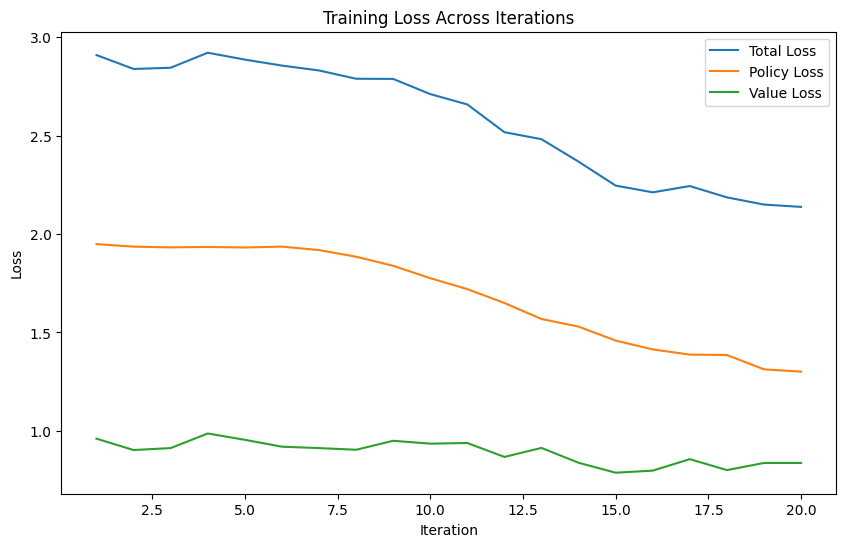

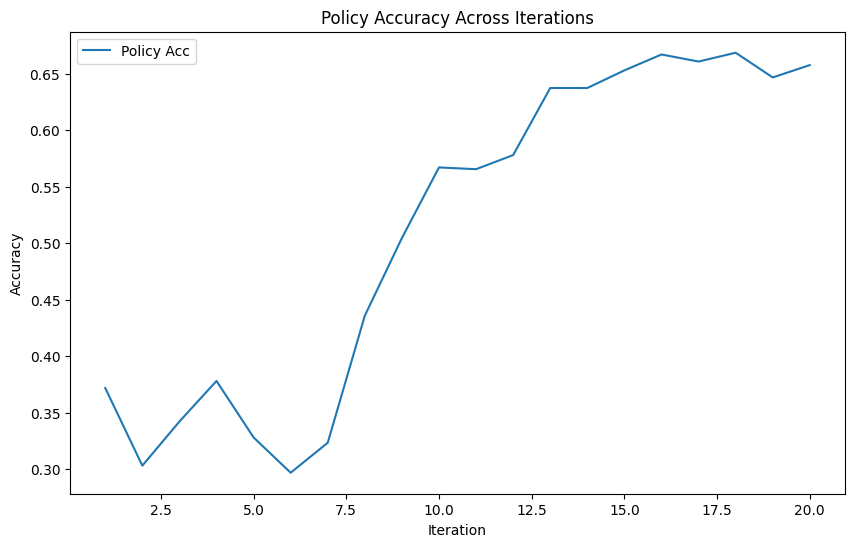

In [ ]:
iterations = [x["iteration"] for x in training_history]
avg_losses = [x["avg_loss"] if x["avg_loss"] is not None else np.nan for x in training_history]
avg_policy_losses = [x["avg_policy_loss"] if x["avg_policy_loss"] is not None else np.nan for x in training_history]
avg_value_losses = [x["avg_value_loss"] if x["avg_value_loss"] is not None else np.nan for x in training_history]
avg_policy_accs = [x["avg_policy_acc"] if x["avg_policy_acc"] is not None else np.nan for x in training_history]

plt.figure(figsize=(10, 6))
plt.plot(iterations, avg_losses, label="Total Loss")
plt.plot(iterations, avg_policy_losses, label="Policy Loss")
plt.plot(iterations, avg_value_losses, label="Value Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss Across Iterations")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(iterations, avg_policy_accs, label="Policy Acc")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Policy Accuracy Across Iterations")
plt.legend()
plt.show()

## Evaluation: Trained Network vs Random

After training, we would like to test whether the learned network can play better than a random agent **without using MCTS**.

In this evaluation, the trained agent selects actions directly from the **policy head** of the neural network.  
The **value head** is still predicted for each position, but it is not used for action selection.

This allows us to measure whether the network itself has learned a meaningful policy from self-play.

**Note:** The game outcome returned by the evaluation code is still defined from the **fixed black-player perspective**:
- black win = `+1`
- white win = `-1`
- draw = `0`

Therefore, if the network plays as **white**, a return value of `-1` means the network wins.

In [ ]:
def select_action_from_network(state, net, device="cpu"):
    """
    Select an action directly from the policy head of the network.
    Illegal actions are masked out before selecting the move.
    """
    # TODO: encode the state and move it to the target device
    state_tensor = encode_state(state).unsqueeze(0).to(device)

    net.eval()
    with torch.no_grad():
        # TODO: run a forward pass through the network
        policy_logits, value = net(state_tensor)

    # TODO: convert the policy logits into probabilities
    probs = torch.softmax(policy_logits, dim=1).squeeze(0).cpu().numpy()

    # TODO: mask out illegal actions
    legal_actions = state.legal_actions()
    mask = np.zeros(7, dtype=np.float32)
    for a in legal_actions:
        mask[a] = 1.0
    masked_probs = probs * mask

    # TODO: renormalize the legal-action probabilities
    prob_sum = masked_probs.sum()
    if prob_sum > 0:
        masked_probs /= prob_sum
    else:
        for a in legal_actions:
            masked_probs[a] = 1.0 / len(legal_actions)

    # TODO: select the legal action with the highest probability
    action = int(np.argmax(masked_probs))

    return action, masked_probs, float(value.item())


def play_network_vs_random(net, network_player=1, seed=None, verbose=False, device="cpu"):
    """
    Play one game between the trained network and a random agent.

    Args:
        network_player:
            1 = network plays black
            2 = network plays white

    Returns:
        result from the fixed black-player perspective:
            +1 if black wins
            -1 if white wins
             0 if draw
    """
    if seed is not None:
        np.random.seed(seed)

    state = ConnectFourState()

    if verbose:
        print("Initial board")
        print_search_board(state)

    move_idx = 0

    while not state.is_terminal():
        if state.current_player == network_player:
            action, policy_probs, pred_value = select_action_from_network(state, net, device=device)
            player_name = "Network"
        else:
            legal_actions = state.legal_actions()
            action = np.random.choice(legal_actions)
            policy_probs = None
            pred_value = None
            player_name = "Random"


        state = state.apply_action(action)

        if verbose:
            print(f"Move {move_idx}: {player_name} -> action {action}")
            print_search_board(state)

            if policy_probs is not None:
                print("Predicted policy:", np.round(policy_probs, 3))
                print(f"Predicted value (black perspective): {pred_value:.3f}")
                print()

        move_idx += 1

    final_value = terminal_value_black_perspective(state)

    if verbose:
        if final_value == 1:
            print("Black wins!")
        elif final_value == -1:
            print("White wins!")
        else:
            print("Draw!")

    return final_value

## Evaluating the Trained Network Against Random Play

We now run multiple games to evaluate the overall performance of the trained network against a random agent.

To make the comparison fairer, the trained network alternates between playing as **black** and **white**.

You do **not** need to modify the code in this part. Just run it to compute the overall win, loss, and draw statistics.

In [ ]:
def evaluate_network_vs_random(net, num_games=50, device="cpu"):
    results = {
        "network_win": 0,
        "random_win": 0,
        "draw": 0,
    }

    for i in range(num_games):
        # Alternate the side played by the trained network
        network_player = 1 if i % 2 == 0 else 2

        final_value = play_network_vs_random(
            net=net,
            network_player=network_player,
            seed=i,
            verbose=False,
            device=device,
        )

        # final_value is always from the fixed black-player perspective
        if network_player == 1:  # network plays black
            if final_value == 1:
                results["network_win"] += 1
            elif final_value == -1:
                results["random_win"] += 1
            else:
                results["draw"] += 1
        else:  # network plays white
            if final_value == -1:
                results["network_win"] += 1
            elif final_value == 1:
                results["random_win"] += 1
            else:
                results["draw"] += 1

    return results

## Evaluation Results

We now report the overall results of the trained network against the random agent.

⚠️ **Do not modify the evaluation code in this part. Any changes to this code will result in a score of 0 for this part.**

In [ ]:
num_games = 50
results = evaluate_network_vs_random(net, num_games=num_games, device=device)

network_win_rate = results["network_win"] / num_games

print(f"Trained Network vs Random over {num_games} games")
print(f"Network wins: {results['network_win']}")
print(f"Random wins: {results['random_win']}")
print(f"Draws: {results['draw']}")
print(f"Network win rate: {network_win_rate:.3f}")

Trained Network vs Random over 50 games
Network wins: 43
Random wins: 7
Draws: 0
Network win rate: 0.860


## Evaluation: Policy-Value + MCTS vs Rollout-Based MCTS

After evaluating the trained network policy alone, we now compare the full **policy-value + MCTS** agent against the **rollout-based MCTS** agent from Question 1.

This comparison is more meaningful than evaluating against a random agent, because both sides now use search. The key difference is whether the search is guided by a learned **policy-value network** or by **random rollouts**.

⚠️ **Do not modify the evaluation code in this part. Any changes to this code will result in a score of 0 for this part.**

In [ ]:
def play_pv_mcts_vs_mcts(
    net,
    pv_mcts_player=1,
    num_simulations_puct=50,
    num_simulations_mcts=50,
    seed=None,
    verbose=False,
    device="cpu",
):
    """
    Play one game between:
    - PV+MCTS (policy-value network + PUCT-based MCTS)
    - rollout-based MCTS from Question 1

    Args:
        net: trained policy-value network
        pv_mcts_player:
            1 = PV+MCTS plays black
            2 = PV+MCTS plays white
        num_simulations_puct: simulations per move for PV+MCTS
        num_simulations_mcts: simulations per move for rollout-based MCTS

    Returns:
        final_value from the fixed black-player perspective:
            +1 if black wins
            -1 if white wins
             0 if draw
    """
    if seed is not None:
        np.random.seed(seed)

    state = ConnectFourState()

    if verbose:
        print("Initial board")
        print_search_board(state)

    move_idx = 0

    while not state.is_terminal():
        if state.current_player == pv_mcts_player:
            root = run_mcts_with_network(
                root_state=state,
                net=net,
                num_simulations=num_simulations_puct,
                c_puct=1.5,
                device=device,
            )
            action = select_action_from_root(root)
            player_name = "PV+MCTS"
        else:
            action, _ = run_mcts(
                root_state=state,
                num_simulations=num_simulations_mcts,
                c=1.4,
            )
            player_name = "MCTS"

        state = state.apply_action(action)

        if verbose:
            print(f"Move {move_idx}: {player_name} -> action {action}")
            print_search_board(state)

        move_idx += 1

    final_value = terminal_value_black_perspective(state)

    if verbose:
        if final_value == 1:
            print("Black wins!")
        elif final_value == -1:
            print("White wins!")
        else:
            print("Draw!")

    return final_value


def evaluate_pv_mcts_vs_mcts(
    net,
    num_games=50,
    num_simulations_puct=50,
    num_simulations_mcts=50,
    device="cpu",
):
    """
    Evaluate PV+MCTS against rollout-based MCTS.

    The PV+MCTS agent alternates between playing black and white.
    """
    results = {
        "pv_mcts_win": 0,
        "mcts_win": 0,
        "draw": 0,
    }

    for i in range(num_games):
        pv_mcts_player = 1 if i % 2 == 0 else 2

        final_value = play_pv_mcts_vs_mcts(
            net=net,
            pv_mcts_player=pv_mcts_player,
            num_simulations_puct=num_simulations_puct,
            num_simulations_mcts=num_simulations_mcts,
            seed=i,
            verbose=False,
            device=device,
        )

        # final_value is always from the fixed black-player perspective
        if pv_mcts_player == 1:  # PV+MCTS plays black
            if final_value == 1:
                results["pv_mcts_win"] += 1
            elif final_value == -1:
                results["mcts_win"] += 1
            else:
                results["draw"] += 1
        else:  # PV+MCTS plays white
            if final_value == -1:
                results["pv_mcts_win"] += 1
            elif final_value == 1:
                results["mcts_win"] += 1
            else:
                results["draw"] += 1

    return results

## Evaluation Results: Policy-Value + MCTS vs Random

We now report the overall results of the trained **policy-value + MCTS** agent against the random agent.

⚠️ **Do not modify the evaluation code in this part. Any changes to this code will result in a score of 0 for this part.**

In [ ]:
num_games = 50
num_simulations_puct = 50
num_simulations_mcts = 50

results = evaluate_pv_mcts_vs_mcts(
    net=net,
    num_games=num_games,
    num_simulations_puct=num_simulations_puct,
    num_simulations_mcts=num_simulations_mcts,
    device=device,
)

pv_mcts_win_rate = results["pv_mcts_win"] / num_games

print(f"PV+MCTS vs MCTS over {num_games} games")
print(f"PV+MCTS wins: {results['pv_mcts_win']}")
print(f"MCTS wins: {results['mcts_win']}")
print(f"Draws: {results['draw']}")
print(f"PV+MCTS win rate: {pv_mcts_win_rate:.3f}")

PV+MCTS vs MCTS over 50 games
PV+MCTS wins: 39
MCTS wins: 11
Draws: 0
PV+MCTS win rate: 0.780


### **Question 1 (2 pts)**

During self-play training, the **policy head** and **value head** are often highly correlated. A state with strong policy recommendations may also have a favorable value estimate.

However, AlphaZero-style search still uses both **policy priors** and **value estimates**.

**If policy and value are already highly correlated, why is the policy head still useful during search? Why not rely only on the value head?**

**Answer:**

While the policy and value heads are often correlated because they stem from the same shared network representation and optimize for the same overall goal, they serve distinct and mechanically complementary roles within the Monte Carlo Tree Search (MCTS) algorithm.

Relying solely on the value head would be highly computationally inefficient for search. The value network evaluates the quality of a specific state. To decide which action to explore next using only the value head, the algorithm would have to simulate taking every possible action, transition to all resulting child states, and run a forward pass of the network for each individual child state to compare them.

The policy head, in contrast, outputs a probability distribution over all possible actions from the current state in a single forward pass. This provides an immediate prior that guides the MCTS. It drastically narrows the search space by acting as a heuristic that tells the algorithm where to look first, focusing search expansions on the most promising branches before the child states are actually evaluated by the value head.

Essentially, the policy network provides breadth-pruning (dictating search direction and prioritizing actions), while the value network provides depth-truncation (evaluating how good those chosen paths actually turn out to be).

---

### **Question 2 (2 pts)**

In the AlphaZero-style training loop, each iteration usually contains two stages:

1. generate new self-play data,
2. update the network for several training steps.

**How does the number of training steps per iteration affect learning? Is there an ideal number of training steps per iteration? Explain your answer.**

**Answer:**

The number of training steps per iteration controls the critical balance between data generation (exploration) and network optimization (exploitation).

* Too few training steps: The network will underfit the current data in the replay buffer. It won't extract enough meaningful information from the newly generated self-play games, leading to highly inefficient learning where computational resources are wasted generating data that is barely learned from.

* Too many training steps: The network risks overfitting to the specific, limited set of games currently in the replay buffer. This can cause the network to memorize recent scenarios rather than generalizing, often leading to policy collapse or catastrophic forgetting, where the agent becomes overly specialized against its most recent self but performs poorly against broader strategies.

* Is there an ideal number? There is no universal "ideal" number; it is a tuned hyperparameter (often referred to as the replay ratio). The optimal number depends on the complexity of the environment, the size of the replay buffer, and the learning rate. The goal is to find a sweet spot where the network loss decreases sufficiently to improve the policy for the next self-play phase, but stops before the network begins to overfit the current buffer's distribution.

---

### **Question 3 (2 pts)**

In this assignment, self-play data is stored in a **replay buffer**, and the network is updated using mini-batches sampled from both recent and older games.

This means the network is repeatedly trained on data generated by **older versions of the policy**.

**Why do we still use a replay buffer? Would it be better to train only on the newest self-play games? Explain the trade-offs.**

**Answer:**

We use a replay buffer primarily to stabilize training by breaking the strong temporal correlations that exist between consecutive states in a single game or a small batch of recent games. Sampling from a buffer ensures the training data is more diverse and closer to being independent and identically distributed (i.i.d.), which is an underlying assumption for effectively training deep neural networks. It also improves sample efficiency by reusing expensive self-play data multiple times.

Training only on the newest self-play games is generally not better and introduces significant drawbacks:

* The Trade-off of Newest Data Only: While training on the newest games ensures the value and policy targets are perfectly aligned with the current network (on-policy), it frequently leads to catastrophic forgetting. The agent will quickly adapt to beat its current specific playstyle but may entirely forget how to counter older, simpler strategies. This often results in "cyclic learning," where the agent's strategy endlessly chases its own tail rather than converging on a globally robust optimal policy.

* The Trade-off of the Replay Buffer: A replay buffer solves the forgetting problem by forcing the network to remain competent against a wide distribution of past states and strategies. The main downside is that the buffer contains off-policy data generated by older, weaker versions of the network. If the buffer is kept too large, the network wastes time training on highly sub-optimal data, which can slow down convergence in the later stages of training.